# 01 — Exploration et Merge des Datasets

> **Objectif du projet, en 2 étages** — Étage 1 (principal, §8) : prédire *les nominations* aux Oscars ; Étage 2 (bonus, `Model_experimentation.ipynb`) : le *gagnant* parmi les nominés. Ce notebook produit les **deux** datasets : `oscar_imdb_merged.parquet` (nominés enrichis) et `oscar_nomination_dataset.parquet` (univers déligibles labellisés, 7 catégories).

**Objectif** : Explorer les donnees IMDb et Oscar, les filtrer, les nettoyer et les fusionner en un seul dataset exploitable pour la suite du projet.

**Sources** :
- IMDb Non-Commercial Datasets (TSV, ~10 Go)
- Oscar nominations/winners (CSV, scraping Wikipedia)

**Perimetre** : Films nomines aux Oscars entre 2000 et 2025.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

RAW_DIR = os.path.join("..", "Data", "Raw")
IMDB_DIR = os.path.join(RAW_DIR, "IMDb")
PROCESSED_DIR = os.path.join("..", "Data", "Processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

## 1. Exploration du dataset Oscar

In [2]:
oscars_raw = pd.read_csv(os.path.join(RAW_DIR, "Scraping", "all_data_oscars.csv"))
print(oscars_raw.shape)
oscars_raw.head(10)

(2194, 7)


,ceremony_number,year,date,url,category,winner,nominees
0,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Outstanding Picture,Wings,The Racket | 7th Heaven
1,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Unique and Artistic Picture,Sunrise,Chang | The Crowd
2,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Directing (Dramatic Picture),Frank Borzage,Herbert Brenon | King Vidor
3,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Directing (Comedy Picture),Lewis Milestone,Charles Chaplin | Ted Wilde
4,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Actor,Emil Jannings,Richard Barthelmess | Charles Chaplin
5,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Actress,Janet Gaynor,Louise Dresser | Gloria Swanson
6,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Writing (Adaptation),7th Heaven,Glorious Betsy | The Jazz Singer
7,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Writing (Original Story),Underworld,The Circus | The Last Command
8,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Writing (Title Writing),Joseph Farnham,Gerald Duffy [ B ] | George Marion Jr.
9,1,1929,"May 16, 1929(1929-05-16)",https://en.wikipedia.org/wiki/1st_Academy_Awards,Best Art Direction,The Dove,NaN


In [3]:
oscars_raw.info()
print(f"\nValeurs manquantes:\n{oscars_raw.isnull().sum()}")
print(f"\nAnnees: {oscars_raw['year'].min()} - {oscars_raw['year'].max()}")
print(f"Categories uniques: {oscars_raw['category'].nunique()}")

<class 'pandas.DataFrame'>
RangeIndex: 2194 entries, 0 to 2193
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ceremony_number  2194 non-null   int64
 1   year             2194 non-null   int64
 2   date             2194 non-null   str  
 3   url              2194 non-null   str  
 4   category         2194 non-null   str  
 5   winner           2194 non-null   str  
 6   nominees         2183 non-null   str  
dtypes: int64(2), str(5)
memory usage: 516.1 KB

Valeurs manquantes:
ceremony_number     0
year                0
date                0
url                 0
category            0
winner              0
nominees           11
dtype: int64

Annees: 1929 - 2026
Categories uniques: 119


### 1.1 Filtrage sur la periode 2000-2025

On garde uniquement les ceremonies a partir de 2000 (72e ceremonie). Les categories Oscar ont evolue au fil du temps — on va les normaliser pour regrouper les variantes (ex: "Best Actor" et "Best Actor in a Leading Role").

In [4]:
# Filtrer 2000+
oscars = oscars_raw[oscars_raw["year"] >= 2000].copy()
print(f"Lignes apres filtrage 2000+: {len(oscars)}")

# Categories presentes dans cette periode
oscars["category"].value_counts()

Lignes apres filtrage 2000+: 641


category
Best Picture                                                                    27
Best Directing                                                                  27
Best Actor in a Leading Role                                                    27
Best Actress in a Leading Role                                                  27
Best Actor in a Supporting Role                                                 27
Best Actress in a Supporting Role                                               27
Best Music (Original Score)                                                     27
Best Music (Original Song)                                                      27
Best Cinematography                                                             27
Best Costume Design                                                             27
Best Film Editing                                                               27
Best Visual Effects                                                           

In [5]:
# Normalisation des categories (regrouper les variantes historiques)
CATEGORY_MAP = {
    # Acteurs
    "Best Actor": "Best Actor in a Leading Role",
    "Best Actress": "Best Actress in a Leading Role",
    # Ecriture
    "Best Writing (Screenplay Written Directly for the Screen)": "Best Writing (Original Screenplay)",
    "Best Writing (Screenplay Based on Material Previously Produced or Published)": "Best Writing (Adapted Screenplay)",
    "Best Writing (Adapted Screenplay)[22]": "Best Writing (Adapted Screenplay)",
    "Best Writing (Adapted Screenplay)[24]": "Best Writing (Adapted Screenplay)",
    "Best  Writing (Screenplay -- Original)": "Best Writing (Original Screenplay)",
    # Film international
    "Best Foreign Language Film": "Best International Feature Film",
    "Best Foreign Language Film[14]": "Best International Feature Film",
    # Art Direction -> Production Design
    "Best Art Direction": "Best Production Design",
    "Best Art Direction (Black-and-White)": "Best Production Design",
    "Best Art Direction (Color)": "Best Production Design",
    # Son
    "Best Sound Recording": "Best Sound",
    "Best Sound Mixing": "Best Sound",
    "Best Sound Effects Editing": "Best Sound Editing",
    # Maquillage
    "Best Makeup": "Best Makeup and Hairstyling",
    # Documentaires
    "Best Documentary (Feature)": "Best Documentary Feature Film",
    "Best Documentary (Short Subject)": "Best Documentary Short Film",
    # Courts-metrages
    "Best Short Subject (Animated)": "Best Short Film (Animated)",
    "Best Short Subject (Cartoon)": "Best Short Film (Animated)",
    "Best Animated Short Film": "Best Short Film (Animated)",
    "Best Live Action Short Film": "Best Short Film (Live Action)",
}

oscars["category_clean"] = oscars["category"].replace(CATEGORY_MAP)
print(f"Categories apres normalisation: {oscars['category_clean'].nunique()}")
oscars["category_clean"].value_counts()

Categories apres normalisation: 25


category_clean
Best Picture                          27
Best Directing                        27
Best Actor in a Leading Role          27
Best Actress in a Leading Role        27
Best Actor in a Supporting Role       27
Best Actress in a Supporting Role     27
Best Writing (Original Screenplay)    27
Best Writing (Adapted Screenplay)     27
Best International Feature Film       27
Best Documentary Feature Film         27
Best Documentary Short Film           27
Best Short Film (Live Action)         27
Best Short Film (Animated)            27
Best Music (Original Score)           27
Best Music (Original Song)            27
Best Sound                            27
Best Production Design                27
Best Cinematography                   27
Best Makeup and Hairstyling           27
Best Costume Design                   27
Best Film Editing                     27
Best Visual Effects                   27
Best Animated Feature Film            25
Best Sound Editing                    21
B

### 1.2 Transformation en format "une ligne = un nomine"

Le dataset Oscar a un format compact : une ligne par categorie/annee avec le winner dans une colonne et les autres nominees separes par `|` dans une autre. On va le transformer en format long (une ligne par nomine) avec une colonne `winner` booleenne.

In [6]:
def explode_oscar_nominations(df):
    """Transforme le dataset Oscar en format long : une ligne par nomine."""
    rows = []
    for _, row in df.iterrows():
        base = {
            "ceremony_number": row["ceremony_number"],
            "year": row["year"],
            "category": row["category_clean"],
        }
        # Le gagnant
        rows.append({**base, "nominee": row["winner"].strip(), "winner": True})
        # Les autres nominees
        if pd.notna(row["nominees"]):
            for nominee in row["nominees"].split("|"):
                nominee = nominee.strip()
                if nominee:
                    rows.append({**base, "nominee": nominee, "winner": False})
    return pd.DataFrame(rows)

oscars_long = explode_oscar_nominations(oscars)
print(f"Shape apres explosion: {oscars_long.shape}")
print(f"Winners: {oscars_long['winner'].sum()}, Nominees: {(~oscars_long['winner']).sum()}")
oscars_long.head(10)

Shape apres explosion: (3153, 5)
Winners: 641, Nominees: 2512


,ceremony_number,year,category,nominee,winner
0,72,2000,Best Picture,American Beauty,True
1,72,2000,Best Picture,The Cider House Rules,False
2,72,2000,Best Picture,The Green Mile,False
3,72,2000,Best Picture,The Insider,False
4,72,2000,Best Picture,The Sixth Sense,False
5,72,2000,Best Directing,Sam Mendes,True
6,72,2000,Best Directing,Lasse Hallström,False
7,72,2000,Best Directing,Spike Jonze,False
8,72,2000,Best Directing,Michael Mann,False
9,72,2000,Best Directing,M. Night Shyamalan,False


### 1.3 Identification des categories "film" vs "personne"

Point crucial : certaines categories nomment des **films** (Best Picture, Best Animated Feature...) et d'autres des **personnes** (Best Actor, Best Director...). Pour le merge avec IMDb, on a besoin du **titre du film** dans tous les cas.

Pour les categories "personne", le nom du film n'est pas dans le dataset Oscar — on devra le retrouver via IMDb (`title.principals` + `name.basics`).

In [7]:
# Categories dont le nominee est un film (le nominee = titre du film)
FILM_CATEGORIES = {
    "Best Picture",
    "Best Animated Feature Film",
    "Best International Feature Film",
    "Best Documentary Feature Film",
    "Best Documentary Short Film",
    "Best Short Film (Animated)",
    "Best Short Film (Live Action)",
    "Best Motion Picture",
    # Categories techniques ou le nominee est generalement un film
    "Best Cinematography",
    "Best Costume Design",
    "Best Film Editing",
    "Best Visual Effects",
    "Best Production Design",
    "Best Sound",
    "Best Sound Editing",
    "Best Makeup and Hairstyling",
    "Best Music (Original Score)",
    "Best Music (Original Song)",
    "Best Writing (Original Screenplay)",
    "Best Writing (Adapted Screenplay)",
}

# Categories dont le nominee est une personne
PERSON_CATEGORIES = {
    "Best Actor in a Leading Role",
    "Best Actress in a Leading Role",
    "Best Actor in a Supporting Role",
    "Best Actress in a Supporting Role",
    "Best Directing",
    "Best Director",
}

oscars_long["nominee_type"] = oscars_long["category"].apply(
    lambda c: "film" if c in FILM_CATEGORIES else ("person" if c in PERSON_CATEGORIES else "other")
)
print(oscars_long["nominee_type"].value_counts())
print(f"\nCategories 'other' (non classees):")
print(oscars_long[oscars_long["nominee_type"] == "other"]["category"].unique())

nominee_type
film      2473
person     675
other        5
Name: count, dtype: int64

Categories 'other' (non classees):
<ArrowStringArray>
['Best Casting']
Length: 1, dtype: str


### 1.4 Focus sur les categories principales

Pour le ML, on se concentre sur les categories les plus stables et pertinentes. On garde les categories "film" et "personne" identifiees ci-dessus, et on ecarte les categories "other" marginales (ex: Best Casting qui n'existe que depuis 2026).

Lignes apres filtrage des categories: 3148 (avant: 3153)
Categories conservees: 24


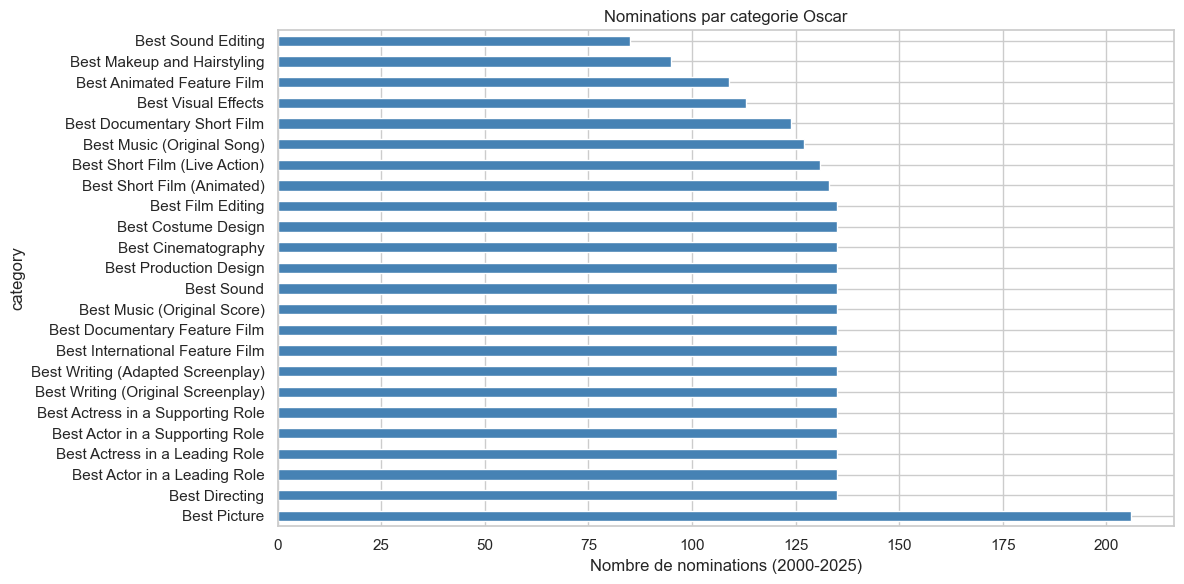

In [8]:
# Garder uniquement les categories film et personne
oscars_filtered = oscars_long[oscars_long["nominee_type"] != "other"].copy()
print(f"Lignes apres filtrage des categories: {len(oscars_filtered)} (avant: {len(oscars_long)})")
print(f"Categories conservees: {oscars_filtered['category'].nunique()}")

# Visualisation : nombre de nominations par categorie
fig, ax = plt.subplots(figsize=(12, 6))
oscars_filtered["category"].value_counts().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Nombre de nominations (2000-2025)")
ax.set_title("Nominations par categorie Oscar")
plt.tight_layout()
plt.show()

## 2. Chargement et filtrage des datasets IMDb

Les fichiers IMDb sont volumineux. Strategie :
1. **`title.basics`** : Filtrer sur `titleType == "movie"` et `startYear >= 1995` (marge pour les films sortis avant la ceremonie 2000)
2. **`title.ratings`** : Merge direct sur `tconst`
3. **`title.crew`** : Realisateurs et scenaristes
4. **`title.principals`** : Casting principal (acteurs, realisateurs)
5. **`name.basics`** : Noms des personnes (pour matcher les nominees "personne")

In [9]:
%%time
# title.basics : tout charger en str pour eviter les erreurs de parsing
# (certains titres contiennent des tabulations qui decalent les colonnes)
title_basics = pd.read_csv(
    os.path.join(IMDB_DIR, "title.basics.tsv"),
    sep="\t",
    na_values="\\N",
    dtype=str,
    on_bad_lines="skip",
)
print(f"Total title.basics: {len(title_basics):,}")
print(f"\ntitleType disponibles:\n{title_basics['titleType'].value_counts()}")

# Filtrer uniquement les longs metrages (movie), pas les series/episodes/courts
movies = title_basics[title_basics["titleType"] == "movie"].copy()
del title_basics

# Convertir les colonnes numeriques apres filtrage
movies["startYear"] = pd.to_numeric(movies["startYear"], errors="coerce").astype("Int64")
movies["runtimeMinutes"] = pd.to_numeric(movies["runtimeMinutes"], errors="coerce").astype("Int64")
movies["isAdult"] = pd.to_numeric(movies["isAdult"], errors="coerce").astype("Int64")

# Filtrer : films 1995+, non-adulte
movies = movies[(movies["startYear"] >= 1995) & (movies["isAdult"] == 0)].copy()

print(f"\nFilms (longs metrages) 1995+, hors adulte: {len(movies):,}")
movies.head()

Total title.basics: 12,420,966



titleType disponibles:
titleType
tvEpisode       9591630
short           1123840
movie            742654
video            324200
tvSeries         297520
tvMovie          154499
tvMiniSeries      69384
tvSpecial         57641
videoGame         48630
tvShort           10967
tvPilot               1
Name: count, dtype: int64



Films (longs metrages) 1995+, hors adulte: 395,657
CPU times: user 23.3 s, sys: 1.94 s, total: 25.3 s
Wall time: 26.2 s


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
11630,tt0011801,movie,Tötet nicht mehr,Tötet nicht mehr,0,2019,NaN,<NA>,"Action,Crime"
34793,tt0035423,movie,Kate & Leopold,Kate & Leopold,0,2001,NaN,118,"Comedy,Fantasy,Romance"
46124,tt0046976,movie,Il figlio dell'uomo,Il figlio dell'uomo,0,2000,NaN,<NA>,NaN
61097,tt0062336,movie,The Tango of the Widower and Its Distorting Mirror,El tango del viudo y su espejo deformante,0,2020,NaN,70,Drama
66093,tt0067460,movie,My Kingdom for...,My Kingdom For...,0,1995,NaN,85,"Documentary,Sport"


In [10]:
%%time
# title.ratings : on ne garde que les films deja filtres
ratings = pd.read_csv(
    os.path.join(IMDB_DIR, "title.ratings.tsv"),
    sep="\t",
    na_values="\\N",
)
# Merge avec movies
movies = movies.merge(ratings, on="tconst", how="left")
del ratings

print(f"Films avec rating: {movies['averageRating'].notna().sum():,} / {len(movies):,}")
movies[["tconst", "primaryTitle", "startYear", "averageRating", "numVotes"]].head(10)

Films avec rating: 222,277 / 395,657
CPU times: user 925 ms, sys: 120 ms, total: 1.04 s
Wall time: 1.05 s


,tconst,primaryTitle,startYear,averageRating,numVotes
0,tt0011801,Tötet nicht mehr,2019,NaN,NaN
1,tt0035423,Kate & Leopold,2001,6.4,93800.0
2,tt0046976,Il figlio dell'uomo,2000,NaN,NaN
3,tt0062336,The Tango of the Widower and Its Distorting Mirror,2020,6.3,274.0
4,tt0067460,My Kingdom for...,1995,6.7,32.0
5,tt0069049,The Other Side of the Wind,2018,6.7,8507.0
6,tt0070080,Barnen från Jordbro,1996,7.3,53.0
7,tt0070596,Socialist Realism,2023,7.0,205.0
8,tt0077684,Histórias de Combóios em Portugal,2022,NaN,NaN
9,tt0082328,Embodiment of Evil,2008,5.9,1930.0


In [11]:
%%time
# title.crew : realisateurs et scenaristes
crew = pd.read_csv(
    os.path.join(IMDB_DIR, "title.crew.tsv"),
    sep="\t",
    na_values="\\N",
)
# Filtrer sur nos films uniquement
crew = crew[crew["tconst"].isin(movies["tconst"])]
movies = movies.merge(crew, on="tconst", how="left")
del crew

print(f"Films avec realisateur: {movies['directors'].notna().sum():,}")
movies[["tconst", "primaryTitle", "directors", "writers"]].head()

Films avec realisateur: 376,850
CPU times: user 12 s, sys: 2.15 s, total: 14.1 s
Wall time: 14.7 s


,tconst,primaryTitle,directors,writers
0,tt0011801,Tötet nicht mehr,nm0681726,"nm0483944,nm0681726"
1,tt0035423,Kate & Leopold,nm0003506,"nm0737216,nm0003506"
2,tt0046976,Il figlio dell'uomo,nm0754670,"nm5461783,nm0274767"
3,tt0062336,The Tango of the Widower and Its Distorting Mirror,"nm0749914,nm0765384","nm0749914,nm1146177"
4,tt0067460,My Kingdom for...,nm0091430,nm0091430


In [12]:
%%time
# title.principals : casting et equipe technique (fichier le plus gros ~4.2 Go)
# On filtre directement sur nos tconst pour limiter la memoire
movie_ids = set(movies["tconst"])
chunks = pd.read_csv(
    os.path.join(IMDB_DIR, "title.principals.tsv"),
    sep="\t",
    na_values="\\N",
    # usecols : on EXCLUT job/characters (longues chaines) -> ~3x moins de memoire,
    # indispensable sur 8 Go. Aucune cellule aval n'utilise ces colonnes.
    usecols=["tconst", "ordering", "nconst", "category"],
    dtype={"category": "category"},
    chunksize=500_000,
)
principals_list = []
for chunk in chunks:
    filtered = chunk[chunk["tconst"].isin(movie_ids)]
    if len(filtered) > 0:
        principals_list.append(filtered)

principals = pd.concat(principals_list, ignore_index=True)
del principals_list

print(f"Principals pour nos films: {len(principals):,}")
print(f"Categories: {principals['category'].value_counts().to_dict()}")
principals.head()

Principals pour nos films: 5,013,087
Categories: {'actor': 1386605, 'actress': 797672, 'producer': 499522, 'writer': 465801, 'director': 415997, 'editor': 356004, 'cinematographer': 351690, 'self': 283248, 'composer': 262992, 'production_designer': 88302, 'casting_director': 82646, 'archive_footage': 22265, 'archive_sound': 343}
CPU times: user 7min 40s, sys: 23.9 s, total: 8min 4s
Wall time: 8min 29s


,tconst,ordering,nconst,category
0,tt0011801,1,nm0681726,actor
1,tt0011801,2,nm0692612,actress
2,tt0011801,3,nm0726256,actor
3,tt0011801,4,nm0776458,actor
4,tt0011801,5,nm0666006,actor


In [13]:
%%time
# name.basics : noms des personnes
# On ne charge que les nconst presents dans principals pour economiser la memoire
person_ids = set(principals["nconst"].dropna())

chunks = pd.read_csv(
    os.path.join(IMDB_DIR, "name.basics.tsv"),
    sep="\t",
    na_values="\\N",
    chunksize=500_000,
)
names_list = []
for chunk in chunks:
    filtered = chunk[chunk["nconst"].isin(person_ids)]
    if len(filtered) > 0:
        names_list.append(filtered)

names = pd.concat(names_list, ignore_index=True)
del names_list

print(f"Personnes chargees: {len(names):,}")
names.head()

Personnes chargees: 1,807,145
CPU times: user 5min 14s, sys: 30.1 s, total: 5min 45s
Wall time: 6min 29s


,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899.0,1987.0,"actor,miscellaneous,producer","tt0050419,tt0072308,tt0027125,tt0025164"
1,nm0000002,Lauren Bacall,1924.0,2014.0,"actress,miscellaneous,soundtrack","tt0037382,tt0075213,tt0038355,tt0045891"
2,nm0000003,Brigitte Bardot,1934.0,2025.0,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949.0,1982.0,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918.0,2007.0,"writer,director,actor","tt0050986,tt0069467,tt0083922,tt0050976"


## 3. Exploration rapide des donnees IMDb

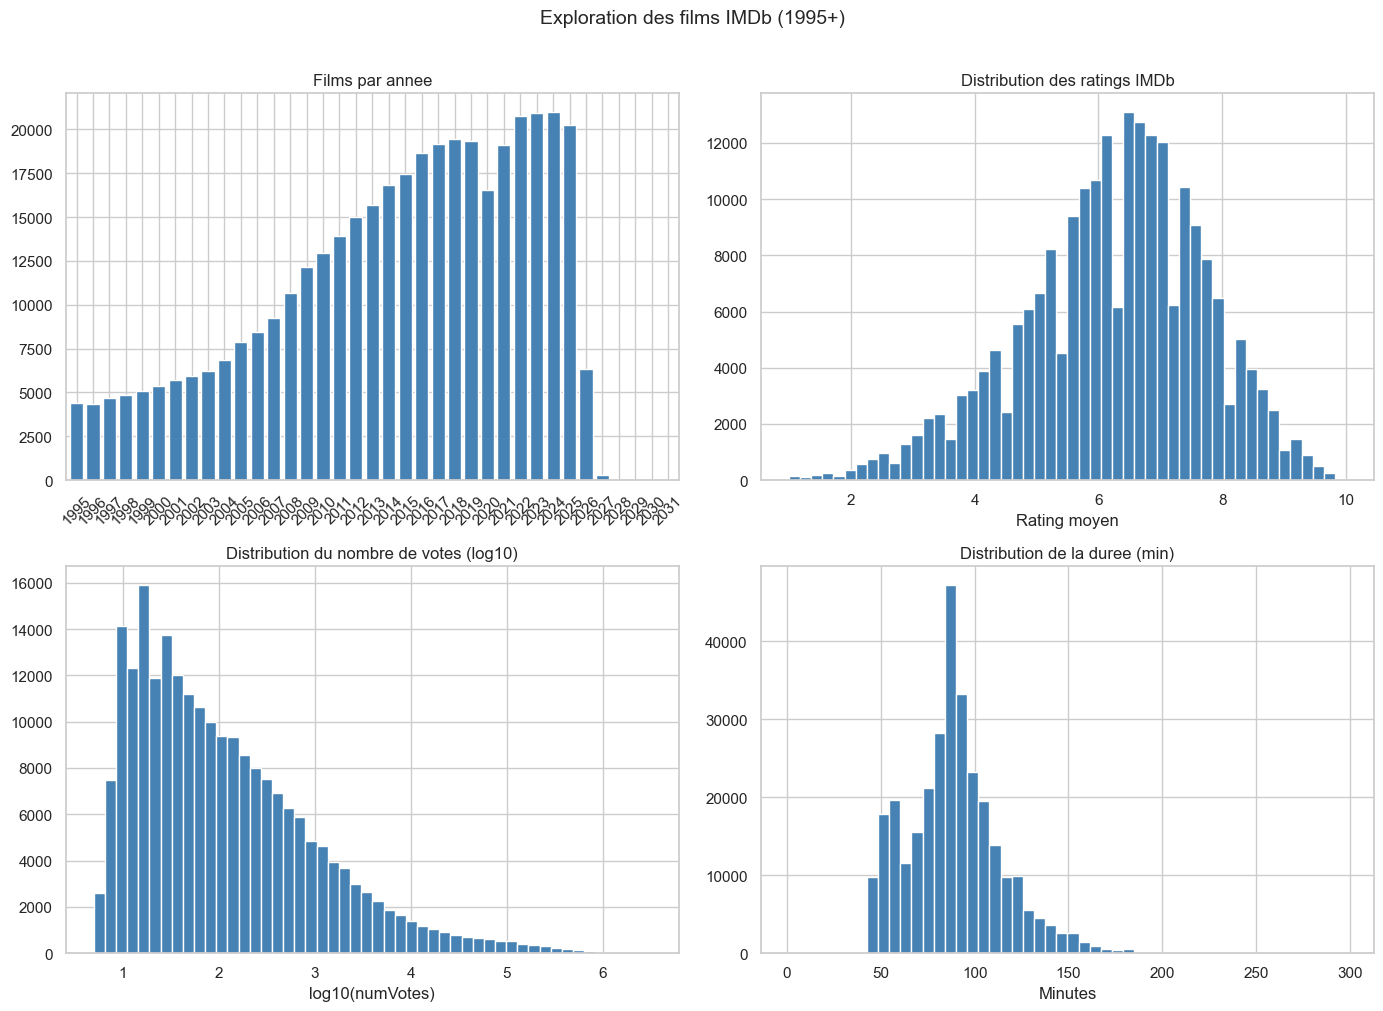

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution des annees
movies["startYear"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="steelblue", width=0.8)
axes[0, 0].set_title("Films par annee")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=45)

# Distribution des ratings
movies["averageRating"].dropna().hist(bins=50, ax=axes[0, 1], color="steelblue", edgecolor="white")
axes[0, 1].set_title("Distribution des ratings IMDb")
axes[0, 1].set_xlabel("Rating moyen")

# Distribution du nombre de votes (log)
movies["numVotes"].dropna().apply(np.log10).hist(bins=50, ax=axes[1, 0], color="steelblue", edgecolor="white")
axes[1, 0].set_title("Distribution du nombre de votes (log10)")
axes[1, 0].set_xlabel("log10(numVotes)")

# Distribution de la duree
runtime = movies["runtimeMinutes"].dropna()
runtime = runtime[(runtime > 0) & (runtime < 300)]
runtime.hist(bins=50, ax=axes[1, 1], color="steelblue", edgecolor="white")
axes[1, 1].set_title("Distribution de la duree (min)")
axes[1, 1].set_xlabel("Minutes")

plt.suptitle("Exploration des films IMDb (1995+)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Stats descriptives des films
movies[["startYear", "runtimeMinutes", "averageRating", "numVotes"]].describe()

,startYear,runtimeMinutes,averageRating,numVotes
count,395657.0,304922.0,222277.000000,2.222770e+05
mean,2014.421011,90.542427,6.225254,4.545350e+03
std,7.925781,142.821771,1.482135,4.178522e+04
min,1995.0,1.0,1.000000,5.000000e+00
25%,2009.0,73.0,5.300000,2.100000e+01
50%,2016.0,90.0,6.400000,7.100000e+01
75%,2021.0,102.0,7.200000,3.880000e+02
max,2031.0,51420.0,10.000000,3.155324e+06


## 4. Merge Oscar ↔ IMDb

### Strategie de matching

**Categories "film"** (Best Picture, etc.) : le `nominee` est un titre de film → match par `primaryTitle` + proximite d'annee (l'annee Oscar correspond a la ceremonie, le film sort generalement 1-2 ans avant).

**Categories "personne"** (Best Actor, etc.) : le `nominee` est un nom de personne → match par `primaryName` dans `name.basics`, puis on retrouve le film via `title.principals`.

In [16]:
# Index de lookup : titre -> liste de (tconst, year)
title_lookup = (
    movies[["tconst", "primaryTitle", "startYear"]]
    .dropna(subset=["startYear"])
    .groupby("primaryTitle")
    .apply(lambda g: list(zip(g["tconst"], g["startYear"])), include_groups=False)
    .to_dict()
)

# Index de lookup : nom de personne -> nconst
name_lookup = (
    names[["nconst", "primaryName"]]
    .groupby("primaryName")["nconst"]
    .apply(list)
    .to_dict()
)

print(f"Titres indexes: {len(title_lookup):,}")
print(f"Noms indexes: {len(name_lookup):,}")

Titres indexes: 352,783
Noms indexes: 1,662,826


### 4.1 Matching des categories "film"

On cherche le `tconst` IMDb correspondant a chaque titre de film nomine. En cas de titre ambigu (plusieurs films avec le meme nom), on prend celui dont l'annee de sortie est la plus proche de l'annee de la ceremonie Oscar (generalement 0 a 2 ans avant).

In [17]:
def match_film_to_imdb(title, oscar_year, lookup):
    """Trouve le tconst IMDb le plus probable pour un titre de film nomine aux Oscars.
    
    La ceremonie Oscar d'une annee N recompense des films sortis en N-1 (parfois N-2).
    On cherche le film avec l'annee la plus proche dans la fenetre [N-3, N].
    """
    # Nettoyer le titre (enlever les annotations entre parentheses pour les films internationaux)
    clean_title = title.split(" (")[0].strip() if " (" in title and title.endswith(")") else title
    
    candidates = lookup.get(title, [])
    if not candidates and clean_title != title:
        candidates = lookup.get(clean_title, [])
    
    if not candidates:
        return None
    
    # Filtrer sur la fenetre temporelle et prendre le plus proche
    scored = [(tc, yr, abs(yr - (oscar_year - 1))) for tc, yr in candidates if oscar_year - 3 <= yr <= oscar_year]
    if not scored:
        return None
    
    scored.sort(key=lambda x: x[2])
    return scored[0][0]  # tconst du meilleur match


# Appliquer le matching sur les categories "film"
oscar_films = oscars_filtered[oscars_filtered["nominee_type"] == "film"].copy()
oscar_films["tconst"] = oscar_films.apply(
    lambda r: match_film_to_imdb(r["nominee"], r["year"], title_lookup), axis=1
)

matched = oscar_films["tconst"].notna().sum()
total = len(oscar_films)
print(f"Matching categories film: {matched}/{total} ({matched/total:.1%})")
print(f"\nNon matches:")
not_matched = oscar_films[oscar_films["tconst"].isna()][["year", "category", "nominee"]]
print(not_matched.to_string(index=False) if len(not_matched) > 0 else "Tous matches !")

Matching categories film: 1769/2473 (71.5%)

Non matches:
 year                           category                                                                                                nominee
 2000    Best International Feature Film                                                                 All About My Mother (Spain) in Spanish
 2000    Best International Feature Film                                                                           East/West (France) in French
 2000    Best International Feature Film                                                                  Himalaya: Caravan (Nepal) in Nepalese
 2000    Best International Feature Film                                                             Solomon & Gaenor (United Kingdom) in Welsh
 2000    Best International Feature Film                                                                      Under the Sun (Sweden) in Swedish
 2000        Best Documentary Short Film                                      

### 4.2 Matching des categories "personne"

Pour les acteurs et realisateurs, on doit :
1. Trouver le `nconst` IMDb a partir du nom
2. Retrouver le film pour lequel ils sont nomines via `title.principals` (en croisant avec l'annee de la ceremonie)

C'est plus complexe car une personne peut avoir joue dans plusieurs films la meme annee.

In [18]:
# Creer un index (nconst, annee_film) -> tconst pour retrouver le film d'une personne
# On merge principals avec movies pour avoir l'annee du film
principals_with_year = principals.merge(
    movies[["tconst", "startYear"]], on="tconst", how="inner"
)

# Index : (nconst) -> liste de (tconst, startYear, category)
person_film_index = (
    principals_with_year
    .groupby("nconst")
    .apply(lambda g: list(zip(g["tconst"], g["startYear"], g["category"])), include_groups=False)
    .to_dict()
)
print(f"Personnes dans l'index: {len(person_film_index):,}")

Personnes dans l'index: 1,807,418


In [19]:
# Mapping entre categorie Oscar et role IMDb dans principals
OSCAR_TO_IMDB_ROLE = {
    "Best Actor in a Leading Role": {"actor"},
    "Best Actress in a Leading Role": {"actress"},
    "Best Actor in a Supporting Role": {"actor"},
    "Best Actress in a Supporting Role": {"actress"},
    "Best Directing": {"director"},
    "Best Director": {"director"},
}


def match_person_to_film(person_name, oscar_year, oscar_category, name_lookup, film_index):
    """Trouve le tconst du film pour lequel une personne est nommee aux Oscars.
    
    1. Trouve le nconst de la personne via son nom
    2. Cherche dans ses films celui de l'annee correspondante avec le bon role
    """
    nconst_list = name_lookup.get(person_name, [])
    if not nconst_list:
        return None, None
    
    expected_roles = OSCAR_TO_IMDB_ROLE.get(oscar_category, set())
    
    best_match = None
    best_score = float("inf")
    best_nconst = None
    
    for nconst in nconst_list:
        films = film_index.get(nconst, [])
        for tconst, film_year, role in films:
            if film_year is None:
                continue
            year_diff = abs(film_year - (oscar_year - 1))
            # Le film doit etre dans la bonne fenetre temporelle
            if oscar_year - 3 <= film_year <= oscar_year:
                # Bonus si le role correspond
                role_match = 1 if (not expected_roles or role in expected_roles) else 0
                score = year_diff - role_match * 0.5  # Priorite au role correct
                if score < best_score:
                    best_score = score
                    best_match = tconst
                    best_nconst = nconst
    
    return best_match, best_nconst


# Appliquer sur les categories "personne"
oscar_persons = oscars_filtered[oscars_filtered["nominee_type"] == "person"].copy()
results = oscar_persons.apply(
    lambda r: match_person_to_film(r["nominee"], r["year"], r["category"], name_lookup, person_film_index),
    axis=1,
    result_type="expand",
)
oscar_persons["tconst"] = results[0]
oscar_persons["nconst"] = results[1]

matched = oscar_persons["tconst"].notna().sum()
total = len(oscar_persons)
print(f"Matching categories personne: {matched}/{total} ({matched/total:.1%})")
print(f"\nNon matches (echantillon):")
not_matched = oscar_persons[oscar_persons["tconst"].isna()][["year", "category", "nominee"]]
print(not_matched.head(20).to_string(index=False))

Matching categories personne: 658/675 (97.5%)

Non matches (echantillon):
 year                          category                                       nominee
 2001   Best Actor in a Supporting Role                              Benicio del Toro
 2004   Best Actor in a Supporting Role                              Benicio del Toro
 2007                    Best Directing                   Alejandro González Iñárritu
 2007 Best Actress in a Supporting Role                               Adriana Barraza
 2008                    Best Directing                      Joel Coen and Ethan Coen
 2008    Best Actress in a Leading Role   Elliot Page (nominated as Ellen Page) [ a ]
 2009   Best Actor in a Supporting Role Heath Ledger † – The Dark Knight as The Joker
 2011                    Best Directing                      Joel Coen and Ethan Coen
 2015   Best Actor in a Supporting Role                                 J. K. Simmons
 2019                    Best Directing                           

### 4.3 Fusion des deux parties et enrichissement IMDb

In [20]:
# Reunir les deux parties
oscar_films["nconst"] = None  # Les categories film n'ont pas de nconst
oscar_all = pd.concat([oscar_films, oscar_persons], ignore_index=True)

# Ne garder que les lignes matchees avec IMDb
oscar_matched = oscar_all[oscar_all["tconst"].notna()].copy()
print(f"Total nominations matchees: {len(oscar_matched)} / {len(oscar_all)} ({len(oscar_matched)/len(oscar_all):.1%})")

# Enrichir avec les donnees IMDb du film
oscar_enriched = oscar_matched.merge(
    movies[["tconst", "primaryTitle", "originalTitle", "startYear", "runtimeMinutes",
            "genres", "averageRating", "numVotes", "directors", "writers"]],
    on="tconst",
    how="left",
)

print(f"\nShape du dataset enrichi: {oscar_enriched.shape}")
oscar_enriched.head()

Total nominations matchees: 2427 / 3148 (77.1%)



Shape du dataset enrichi: (2427, 17)


,ceremony_number,year,category,nominee,winner,nominee_type,tconst,nconst,primaryTitle,originalTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,directors,writers
0,72,2000,Best Picture,American Beauty,True,film,tt0169547,None,American Beauty,American Beauty,1999,122,Drama,8.3,1277454.0,nm0005222,nm0050332
1,72,2000,Best Picture,The Cider House Rules,False,film,tt0124315,None,The Cider House Rules,The Cider House Rules,1999,126,"Drama,Romance",7.4,109318.0,nm0002120,nm0410288
2,72,2000,Best Picture,The Green Mile,False,film,tt0120689,None,The Green Mile,The Green Mile,1999,189,"Crime,Drama,Fantasy",8.6,1555680.0,nm0001104,"nm0000175,nm0001104"
3,72,2000,Best Picture,The Insider,False,film,tt0140352,None,The Insider,The Insider,1999,157,"Biography,Drama,History",7.8,191994.0,nm0000520,"nm0107493,nm0744839,nm0000520"
4,72,2000,Best Picture,The Sixth Sense,False,film,tt0167404,None,The Sixth Sense,The Sixth Sense,1999,107,"Drama,Mystery,Thriller",8.2,1140786.0,nm0796117,nm0796117


In [21]:
# Ajouter des features derivees du casting (nombre d'acteurs principaux, etc.)
cast_stats = (
    principals[principals["category"].isin(["actor", "actress"])]
    .groupby("tconst")
    .agg(
        n_cast=("nconst", "count"),
    )
)

oscar_enriched = oscar_enriched.merge(cast_stats, on="tconst", how="left")

# Nombre de genres par film
oscar_enriched["n_genres"] = oscar_enriched["genres"].apply(
    lambda x: len(x.split(",")) if pd.notna(x) else 0
)

print(f"Shape final: {oscar_enriched.shape}")
oscar_enriched.info()

Shape final: (2427, 19)
<class 'pandas.DataFrame'>
RangeIndex: 2427 entries, 0 to 2426
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ceremony_number  2427 non-null   int64  
 1   year             2427 non-null   int64  
 2   category         2427 non-null   str    
 3   nominee          2427 non-null   str    
 4   winner           2427 non-null   bool   
 5   nominee_type     2427 non-null   str    
 6   tconst           2427 non-null   object 
 7   nconst           658 non-null    object 
 8   primaryTitle     2427 non-null   str    
 9   originalTitle    2427 non-null   str    
 10  startYear        2427 non-null   Int64  
 11  runtimeMinutes   2417 non-null   Int64  
 12  genres           2426 non-null   str    
 13  averageRating    2414 non-null   float64
 14  numVotes         2414 non-null   float64
 15  directors        2423 non-null   str    
 16  writers          2370 non-null   str    
 17  n

## 5. Visualisations du dataset merge

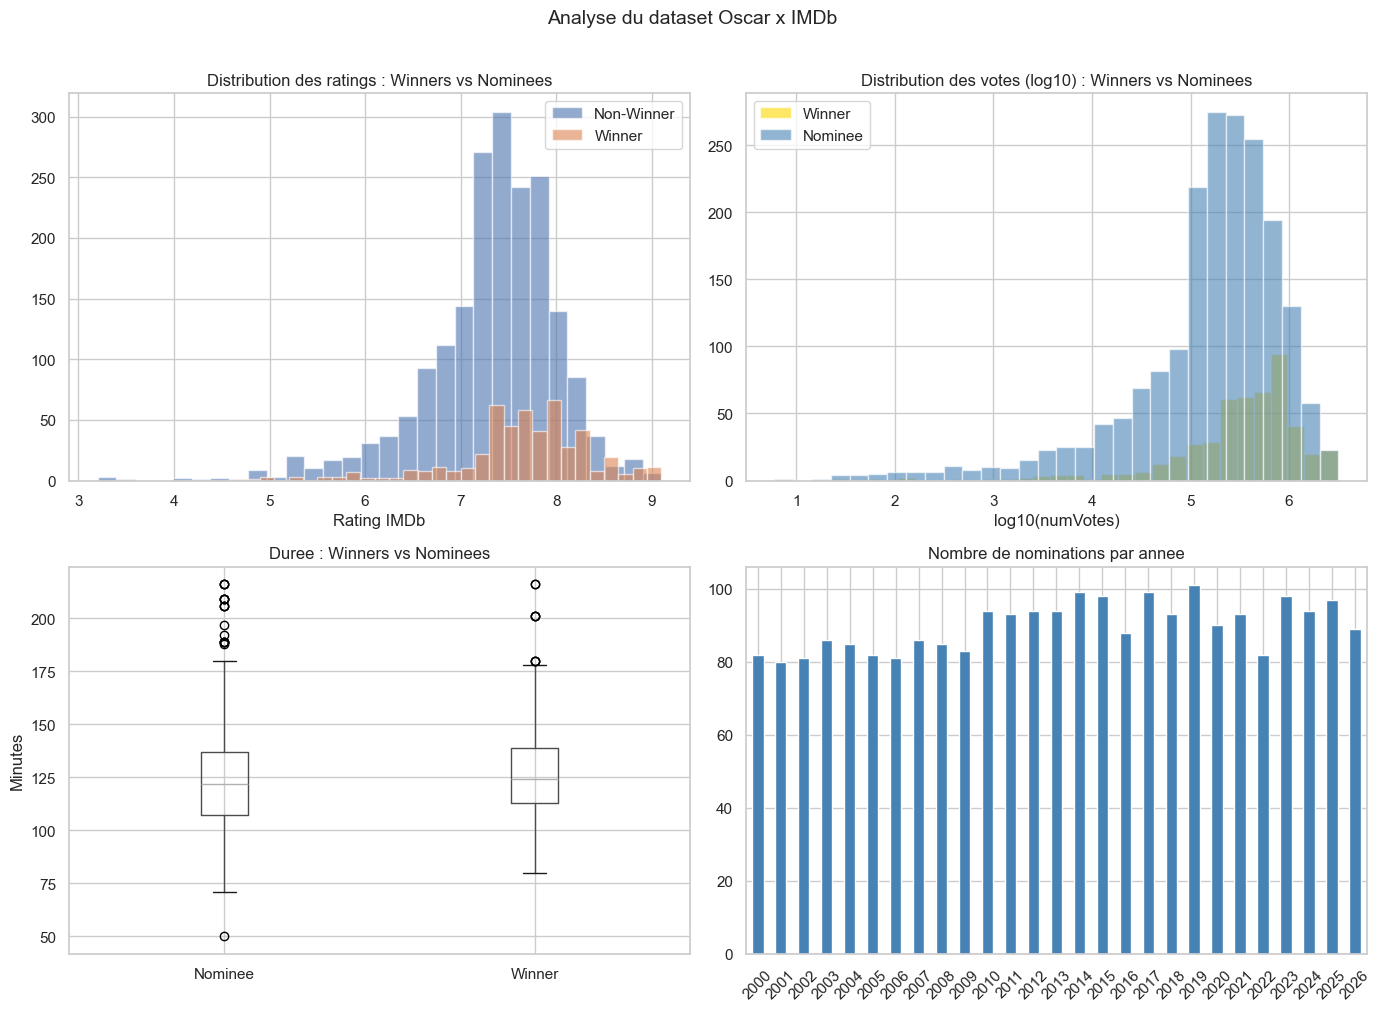

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating moyen : winners vs nominees
oscar_enriched.groupby("winner")["averageRating"].hist(
    bins=30, alpha=0.6, ax=axes[0, 0], legend=True
)
axes[0, 0].set_title("Distribution des ratings : Winners vs Nominees")
axes[0, 0].set_xlabel("Rating IMDb")
axes[0, 0].legend(["Non-Winner", "Winner"])

# Nombre de votes : winners vs nominees
for w, label, color in [(True, "Winner", "gold"), (False, "Nominee", "steelblue")]:
    data = oscar_enriched[oscar_enriched["winner"] == w]["numVotes"].dropna().apply(np.log10)
    axes[0, 1].hist(data, bins=30, alpha=0.6, label=label, color=color)
axes[0, 1].set_title("Distribution des votes (log10) : Winners vs Nominees")
axes[0, 1].set_xlabel("log10(numVotes)")
axes[0, 1].legend()

# Duree des films nommes par categorie (top categories)
top_cats = oscar_enriched["category"].value_counts().head(8).index
subset = oscar_enriched[oscar_enriched["category"].isin(top_cats)]
subset.boxplot(column="runtimeMinutes", by="winner", ax=axes[1, 0])
axes[1, 0].set_title("Duree : Winners vs Nominees")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Minutes")
plt.sca(axes[1, 0])
plt.xticks([1, 2], ["Nominee", "Winner"])

# Nominations par annee
oscar_enriched.groupby("year")["winner"].count().plot(kind="bar", ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Nombre de nominations par annee")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.suptitle("Analyse du dataset Oscar x IMDb", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

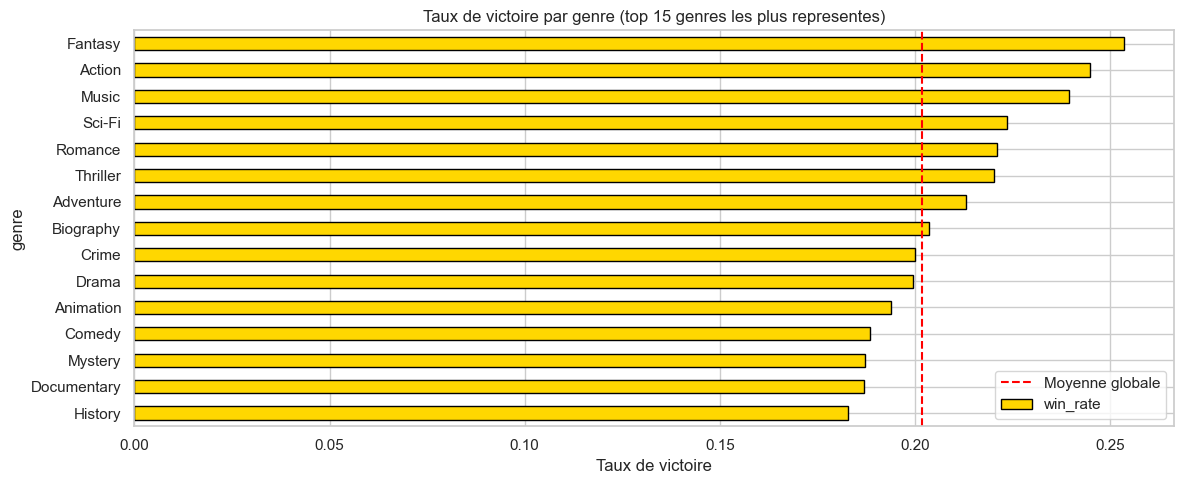

,total,wins,win_rate
genre,,,
Drama,1830,365,0.199454
Adventure,521,111,0.213052
Biography,501,102,0.203593
Comedy,488,92,0.188525
Action,445,109,0.244944
Romance,353,78,0.220963
Crime,350,70,0.200000
History,246,45,0.182927
Thriller,218,48,0.220183


In [23]:
# Taux de victoire par genre (genres les plus representes)
genre_rows = []
for _, row in oscar_enriched.iterrows():
    if pd.notna(row["genres"]):
        for genre in row["genres"].split(","):
            genre_rows.append({"genre": genre.strip(), "winner": row["winner"]})

genre_df = pd.DataFrame(genre_rows)
genre_stats = (
    genre_df.groupby("genre")
    .agg(total=("winner", "count"), wins=("winner", "sum"))
    .assign(win_rate=lambda x: x["wins"] / x["total"])
    .sort_values("total", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
genre_stats["win_rate"].sort_values().plot(kind="barh", ax=ax, color="gold", edgecolor="black")
ax.set_xlabel("Taux de victoire")
ax.set_title("Taux de victoire par genre (top 15 genres les plus representes)")
ax.axvline(x=oscar_enriched["winner"].mean(), color="red", linestyle="--", label="Moyenne globale")
ax.legend()
plt.tight_layout()
plt.show()

genre_stats

## 6. Enrichissement TMDb (plots, keywords, budget, etc.)

On enrichit le dataset avec des donnees TMDb qui ne sont pas presentes dans IMDb :
- `overview` (synopsis), `tagline`
- `keywords` (mots-cles thematiques — particulierement utile pour Best Screenplay / Best Picture)
- `budget`, `revenue` (signaux forts pour Best Picture et categories techniques)
- `original_language`, `production_countries`, `release_date` (date complete vs `film_year` seul)
- `tmdb_vote_average`, `tmdb_vote_count` (complement aux ratings IMDb)

**Volumes** : 1097 films uniques × 2 calls API = ~2200 requetes. Avec un rate limit de 20 req/s, ca prend ~2 minutes au premier run. TMDb n'a plus de quota journalier depuis 2023, donc 1 seule cle API suffit largement.

**Robustesse** :
- **Caching** : les resultats sont sauvegardes incrementalement dans `Data/Processed/tmdb_cache.parquet`.
- **Reprise** : si le notebook est interrompu, le rerun reprend exactement ou il s'etait arrete.
- **Idempotence** : les reruns sans nouveaux films sont instantanes (rien a fetcher).


In [24]:
import time
from pathlib import Path
import requests
from dotenv import load_dotenv

# Charger la cle API depuis le .env a la racine du projet
load_dotenv(Path("..") / ".env")
TMDB_API_KEY = os.getenv("TMDB_API_KEY")
assert TMDB_API_KEY, "TMDB_API_KEY introuvable dans ../.env"

TMDB_BASE_URL = "https://api.themoviedb.org/3"
RATE_LIMIT_SLEEP = 0.05  # 20 req/s, en dessous de la limite TMDb (~50 req/s)
TMDB_CACHE_PATH = Path(PROCESSED_DIR) / "tmdb_cache.parquet"

print(f"Cle TMDb chargee ({len(TMDB_API_KEY)} chars)")
print(f"Cache TMDb : {TMDB_CACHE_PATH}")


Cle TMDb chargee (32 chars)
Cache TMDb : ../Data/Processed/tmdb_cache.parquet


In [25]:
def _tmdb_get(session, path, **params):
    """Appel GET TMDb avec retry simple sur 429 (rate limit)."""
    params["api_key"] = TMDB_API_KEY
    try:
        r = session.get(f"{TMDB_BASE_URL}{path}", params=params, timeout=10)
        if r.status_code == 429:
            time.sleep(int(r.headers.get("Retry-After", 1)))
            r = session.get(f"{TMDB_BASE_URL}{path}", params=params, timeout=10)
        r.raise_for_status()
        return r.json()
    except requests.RequestException as e:
        return {"_error": str(e)}


def fetch_tmdb(session, tconst):
    """Recupere overview, keywords, budget, etc. pour un tconst IMDb (2 calls TMDb)."""
    # Etape 1 : resoudre tconst -> tmdb_id
    find = _tmdb_get(session, f"/find/{tconst}", external_source="imdb_id")
    if "_error" in find:
        return {"tconst": tconst, "error": find["_error"]}

    movies = find.get("movie_results", [])
    if not movies:
        return {"tconst": tconst, "error": "not_found_on_tmdb"}

    tmdb_id = movies[0]["id"]
    time.sleep(RATE_LIMIT_SLEEP)

    # Etape 2 : details + keywords en 1 call (append_to_response)
    detail = _tmdb_get(session, f"/movie/{tmdb_id}", append_to_response="keywords")
    if "_error" in detail:
        return {"tconst": tconst, "tmdb_id": tmdb_id, "error": detail["_error"]}

    return {
        "tconst": tconst,
        "tmdb_id": tmdb_id,
        "overview": detail.get("overview"),
        "tagline": detail.get("tagline"),
        "release_date": detail.get("release_date"),
        "original_language": detail.get("original_language"),
        "keywords": [k["name"] for k in detail.get("keywords", {}).get("keywords", [])],
        "production_countries": [c["iso_3166_1"] for c in detail.get("production_countries", [])],
        "budget": detail.get("budget"),
        "revenue": detail.get("revenue"),
        "tmdb_vote_average": detail.get("vote_average"),
        "tmdb_vote_count": detail.get("vote_count"),
        "error": None,
    }


In [26]:
# Charger le cache existant (reprise apres interruption / reruns instantanes)
if TMDB_CACHE_PATH.exists():
    cache_df = pd.read_parquet(TMDB_CACHE_PATH)
    print(f"Cache existant trouve : {len(cache_df)} films deja recuperes")
else:
    cache_df = pd.DataFrame()
    print("Pas de cache existant, demarrage a zero")

# Liste des tconst uniques a recuperer (hors cache)
all_tconsts = oscar_enriched["tconst"].dropna().unique().tolist()
already_fetched = set(cache_df["tconst"]) if not cache_df.empty else set()
to_fetch = [t for t in all_tconsts if t not in already_fetched]

print(f"Films uniques au total       : {len(all_tconsts)}")
print(f"Deja dans le cache           : {len(already_fetched)}")
print(f"A recuperer via TMDb         : {len(to_fetch)}")
print(f"Estimation temps (~20 req/s) : ~{len(to_fetch) * 2 * RATE_LIMIT_SLEEP:.0f}s")

# Fetch incremental avec sauvegarde periodique (resilience aux interruptions)
SAVE_EVERY = 50
new_records = []
if to_fetch:
    with requests.Session() as session:
        for i, tconst in enumerate(to_fetch, 1):
            rec = fetch_tmdb(session, tconst)
            new_records.append(rec)
            time.sleep(RATE_LIMIT_SLEEP)

            if i % SAVE_EVERY == 0 or i == len(to_fetch):
                # Flush sur disque toutes les SAVE_EVERY iterations
                partial_df = pd.concat(
                    [cache_df, pd.DataFrame(new_records)], ignore_index=True
                )
                partial_df.to_parquet(TMDB_CACHE_PATH, index=False)
                err_count = pd.DataFrame(new_records)["error"].notna().sum()
                print(f"  [{i:4d}/{len(to_fetch)}] flush -> cache: {len(partial_df)} | erreurs: {err_count}")

# Charger le cache final (toujours present apres le loop)
tmdb_df = pd.read_parquet(TMDB_CACHE_PATH)
print(f"\nTotal films dans le cache TMDb : {len(tmdb_df)}")
n_errors = tmdb_df["error"].notna().sum()
print(f"Erreurs                        : {n_errors} ({100*n_errors/len(tmdb_df):.1f}%)")
if n_errors > 0:
    print(f"\nTypes d'erreur:")
    print(tmdb_df[tmdb_df["error"].notna()]["error"].value_counts().to_string())


Cache existant trouve : 1097 films deja recuperes
Films uniques au total       : 1097
Deja dans le cache           : 1097
A recuperer via TMDb         : 0
Estimation temps (~20 req/s) : ~0s

Total films dans le cache TMDb : 1097
Erreurs                        : 16 (1.5%)

Types d'erreur:
error
not_found_on_tmdb    16


In [27]:
# Merger les donnees TMDb dans oscar_enriched (jointure sur tconst)
# tconst peut apparaitre plusieurs fois dans oscar_enriched (1 ligne = 1 nomination),
# donc on dedoublonne le cache TMDb avant le left join.
tmdb_merge_cols = [
    "tconst", "tmdb_id", "overview", "tagline", "release_date",
    "original_language", "keywords", "production_countries",
    "budget", "revenue", "tmdb_vote_average", "tmdb_vote_count",
]

tmdb_unique = tmdb_df.drop_duplicates(subset=["tconst"], keep="last")
oscar_enriched = oscar_enriched.merge(
    tmdb_unique[tmdb_merge_cols], on="tconst", how="left"
)

print(f"Shape apres merge TMDb: {oscar_enriched.shape}")
print(f"\nCouverture des nouveaux champs TMDb:")
for col in tmdb_merge_cols[1:]:
    if col in ("keywords", "production_countries"):
        # listes : on compte les listes non vides
        nn = oscar_enriched[col].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) > 0).sum()
    else:
        nn = oscar_enriched[col].notna().sum()
    pct = 100 * nn / len(oscar_enriched)
    print(f"  {col:25s}: {nn:5d}/{len(oscar_enriched)} ({pct:.1f}%)")


Shape apres merge TMDb: (2427, 30)

Couverture des nouveaux champs TMDb:
  tmdb_id                  :  2406/2427 (99.1%)
  overview                 :  2406/2427 (99.1%)
  tagline                  :  2406/2427 (99.1%)
  release_date             :  2406/2427 (99.1%)
  original_language        :  2406/2427 (99.1%)
  keywords                 :  2358/2427 (97.2%)
  production_countries     :  2391/2427 (98.5%)
  budget                   :  2406/2427 (99.1%)
  revenue                  :  2406/2427 (99.1%)
  tmdb_vote_average        :  2406/2427 (99.1%)
  tmdb_vote_count          :  2406/2427 (99.1%)


## 7. Export du dataset final

In [28]:
# Colonnes finales du dataset
FINAL_COLUMNS = [
    # Identifiants
    "tconst", "nconst", "tmdb_id",
    # Oscar
    "year", "ceremony_number", "category", "nominee", "nominee_type", "winner",
    # Film (IMDb)
    "primaryTitle", "originalTitle", "startYear", "runtimeMinutes", "genres", "n_genres",
    # Popularite (IMDb)
    "averageRating", "numVotes",
    # Equipe
    "directors", "writers", "n_cast",
    # Enrichissement TMDb
    "overview", "tagline", "release_date", "original_language",
    "keywords", "production_countries", "budget", "revenue",
    "tmdb_vote_average", "tmdb_vote_count",
]

dataset_final = oscar_enriched[FINAL_COLUMNS].copy()

# Renommer pour plus de clarte
dataset_final = dataset_final.rename(columns={
    "primaryTitle": "film_title",
    "originalTitle": "film_original_title",
    "startYear": "film_year",
    "runtimeMinutes": "runtime_minutes",
    "averageRating": "imdb_rating",
    "numVotes": "imdb_votes",
})

print(f"Dataset final: {dataset_final.shape}")
print(f"\nValeurs manquantes:")
print(dataset_final.isnull().sum())
print(f"\nApercu:")
dataset_final.head(10)

Dataset final: (2427, 30)

Valeurs manquantes:
tconst                     0
nconst                  1769
tmdb_id                   21
year                       0
ceremony_number            0
category                   0
nominee                    0
nominee_type               0
winner                     0
film_title                 0
film_original_title        0
film_year                  0
runtime_minutes           10
genres                     1
n_genres                   0
imdb_rating               13
imdb_votes                13
directors                  4
writers                   57
n_cast                    98
overview                  21
tagline                   21
release_date              21
original_language         21
keywords                  21
production_countries      21
budget                    21
revenue                   21
tmdb_vote_average         21
tmdb_vote_count           21
dtype: int64

Apercu:


,tconst,nconst,tmdb_id,year,ceremony_number,category,nominee,nominee_type,winner,film_title,film_original_title,film_year,runtime_minutes,genres,n_genres,imdb_rating,imdb_votes,directors,writers,n_cast,overview,tagline,release_date,original_language,keywords,production_countries,budget,revenue,tmdb_vote_average,tmdb_vote_count
0,tt0169547,None,14.0,2000,72,Best Picture,American Beauty,film,True,American Beauty,American Beauty,1999,122,Drama,1,8.3,1277454.0,nm0005222,nm0050332,10.0,"Lester Burnham, a depressed suburban father in a mid-life crisis, decides to...",... look closer,1999-09-15,en,"[estate agent, adultery, coming out, first time, virgin, cheating, parent ch...",[US],15000000.0,356296601.0,8.001,13009.0
1,tt0124315,None,1715.0,2000,72,Best Picture,The Cider House Rules,film,False,The Cider House Rules,The Cider House Rules,1999,126,"Drama,Romance",2,7.4,109318.0,nm0002120,nm0410288,10.0,"Homer is an orphan who was never adopted, becoming the favorite of orphanage...",A story about how far we must travel to find the place where we belong.,1999-12-17,en,"[based on novel or book, orphanage, pregnancy, drug addiction, cigarette, ci...",[US],24000000.0,88500000.0,7.087,1286.0
2,tt0120689,None,497.0,2000,72,Best Picture,The Green Mile,film,False,The Green Mile,The Green Mile,1999,189,"Crime,Drama,Fantasy",3,8.6,1555680.0,nm0001104,"nm0000175,nm0001104",10.0,"A supernatural tale set on death row in a Southern prison, where gentle gian...",Paul Edgecomb didn't believe in miracles. Until the day he met one.,1999-12-10,en,"[mentally disabled, death penalty, based on novel or book, southern usa, psy...",[US],60000000.0,286801374.0,8.505,19209.0
3,tt0140352,None,9008.0,2000,72,Best Picture,The Insider,film,False,The Insider,The Insider,1999,157,"Biography,Drama,History",3,7.8,191994.0,nm0000520,"nm0107493,nm0744839,nm0000520",10.0,A research chemist comes under personal and professional attack when he deci...,Two men driven to tell the truth … whatever the cost.,1999-10-28,en,"[newspaper, research, politics, spy, journalism, interview, tobacco, insider...",[US],90000000.0,60300000.0,7.460,2060.0
4,tt0167404,None,745.0,2000,72,Best Picture,The Sixth Sense,film,False,The Sixth Sense,The Sixth Sense,1999,107,"Drama,Mystery,Thriller",3,8.2,1140786.0,nm0796117,nm0796117,10.0,"Following an unexpected tragedy, child psychologist Malcolm Crowe meets a ni...",Not every gift is a blessing.,1999-08-06,en,"[dying and death, child abuse, philadelphia, pennsylvania, sense of guilt, a...",[US],40000000.0,672800000.0,7.951,12817.0
5,tt0169547,None,14.0,2000,72,Best Writing (Original Screenplay),American Beauty,film,True,American Beauty,American Beauty,1999,122,Drama,1,8.3,1277454.0,nm0005222,nm0050332,10.0,"Lester Burnham, a depressed suburban father in a mid-life crisis, decides to...",... look closer,1999-09-15,en,"[estate agent, adultery, coming out, first time, virgin, cheating, parent ch...",[US],15000000.0,356296601.0,8.001,13009.0
6,tt0120601,None,492.0,2000,72,Best Writing (Original Screenplay),Being John Malkovich,film,False,Being John Malkovich,Being John Malkovich,1999,113,"Comedy,Drama,Fantasy",3,7.7,369104.0,nm0005069,nm0442109,10.0,"One day at work, unsuccessful puppeteer Craig finds a portal into the head o...",Ever wanted to be someone else? Now you can.,1999-10-29,en,"[witch, sexual identity, individual, secret love, transvestism, identity, su...",[US],13000000.0,22863596.0,7.400,4772.0
7,tt0175880,None,334.0,2000,72,Best Writing (Original Screenplay),Magnolia,film,False,Magnolia,Magnolia,1999,188,Drama,1,8.0,349846.0,nm0000759,nm0000759,11.0,"On one random day in the San Fernando Valley, a dying father, a young wife, ...","Things fall down. People look up. And when it rains, it pours.",1999-12-17,en,"[dying and death, daughter, farewell, regret, unsociability, chance, becomin...",[US],37000000.0,48451803.0,7.731,3985.0
8,tt0167404,None,745.0,2000,72,Best Writing (Original Screenplay),The Sixth Sense,film,False,The Sixth Sense,T

In [29]:
# Sauvegarder : Parquet (canonique, conserve les types et les listes) + CSV (inspection)
parquet_path = os.path.join(PROCESSED_DIR, "oscar_imdb_merged.parquet")
csv_path = os.path.join(PROCESSED_DIR, "oscar_imdb_merged.csv")

dataset_final.to_parquet(parquet_path, index=False)
dataset_final.to_csv(csv_path, index=False)

print(f"Dataset sauvegarde (Parquet) : {parquet_path}  ({os.path.getsize(parquet_path)/1024:.0f} KB)")
print(f"Dataset sauvegarde (CSV)     : {csv_path}  ({os.path.getsize(csv_path)/1024:.0f} KB)")
print(f"\nNB : pour le ML, charger le Parquet (preserve les listes keywords / production_countries).")
print(f"     Le CSV est fourni pour inspection rapide mais les listes y sont stringifiees.")

Dataset sauvegarde (Parquet) : ../Data/Processed/oscar_imdb_merged.parquet  (546 KB)
Dataset sauvegarde (CSV)     : ../Data/Processed/oscar_imdb_merged.csv  (1926 KB)

NB : pour le ML, charger le Parquet (preserve les listes keywords / production_countries).
     Le CSV est fourni pour inspection rapide mais les listes y sont stringifiees.


## Recap et prochaines etapes

### Ce qui a ete fait
- Exploration et nettoyage du dataset Oscar (normalisation des categories, format long)
- Chargement et filtrage des datasets IMDb (films 1995+, ratings, crew, principals, noms)
- Matching Oscar ↔ IMDb par titre de film (categories "film") et par nom de personne (categories "personne")
- Enrichissement IMDb (rating, votes, duree, genres, realisateurs, etc.)
- **Enrichissement TMDb** : overview, tagline, keywords, budget, revenue, langue, pays, date de sortie (avec cache pour reruns instantanes)
- Export du dataset fusionne dans `Data/Processed/oscar_imdb_merged.parquet` (+ CSV pour inspection)

### Observations cles
- Les films gagnants tendent a avoir des ratings IMDb legerement plus eleves
- Le nombre de votes (popularite) est un signal potentiellement fort
- Certains genres sont sur-representes parmi les nomines (Drama surtout)
- Les keywords TMDb donnent un signal thematique potentiellement determinant pour les categories scenario

### Prochaines etapes
1. **Feature engineering** : one-hot encoding des genres, vectorisation des keywords (TF-IDF ou embeddings), ROI (revenue/budget), historique de nominations du realisateur/acteur, nombre total de nominations du film par ceremonie
2. **Donnees supplementaires** : critiques (Rotten Tomatoes, Metacritic), buzz Twitter/presse
3. **Modelisation** : classification binaire (winner vs nominee), approche par categorie ou globale
4. **Interface** : Streamlit pour visualiser les predictions
- **§8 — Étage 1 (nomination)** : set négatif « stratégie B+ » + univers éligibles-personnes (`principals`) → `oscar_nomination_dataset.parquet` (7 catégories, ~63k lignes).

## 8. Étage 1 — Prédire les **nominations** aux Oscars (objectif principal)

> **Objectif du projet, en deux étages :**
> 1. **Étage 1 — principal** : prédire *qui sera nominé* dans chaque catégorie (`nominated ∈ {0,1}`).
> 2. **Étage 2 — bonus** : parmi les nominés (prédits), prédire *le gagnant* (cf. `Model_experimentation.ipynb`).
>
> `oscar_imdb_merged.parquet` ne contient que des **positifs** (2 427 nominations). Pour l'étage 1, on construit
> un **univers d'éligibles** par catégorie, dont les **négatifs** = candidats éligibles *non nominés*.

**Périmètre : 7 catégories** (*Best Animated Feature* & *Best Visual Effects* exclus — faible valeur marché
+ aucune spec technique exploitable dans IMDb/TMDb) :
- **Film** (univers = films éligibles) : Best Picture, Best Original Screenplay.
- **Personne** (univers = acteurs / réalisateurs des films éligibles, via `principals`) : Director, Actor,
  Actress, Supporting Actor, Supporting Actress.

**Éligibilité « stratégie B+ » (logique cinéphile, data-driven)** — on retire les films *sans aucune chance* :

| Filtre | Valeur | Justification |
|---|---|---|
| `titleType` / `isAdult` | movie / 0 | longs métrages |
| `startYear` | 1999–2025 | sortie Y-1 → cérémonie Y |
| `runtimeMinutes` | ≥ 60 | exclut les courts métrages |
| `numVotes` | **≥ 10 000** | exposition minimale (sinon jamais « in conversation ») |
| `averageRating` | **≥ 5.0** | exclut les films éreintés par la critique |
| genre | **≠ Documentary** | les documentaires ont leur propre catégorie |

> Ce raffinage retire **~5 000 films** du pool **sans perdre un seul vrai nominé** (les positifs sous le seuil
> sont ré-injectés) → base-rate réaliste ~1–3 %. **Anti-leakage** : on n'utilise que des features connues
> *avant* les nominations (note, votes, durée, genres, décennie, historique Oscar de la personne, billing) ;
> `film_n_total_noms` est exclu (post-nomination). On réutilise `movies`, `principals` et `dataset_final`
> (déjà en mémoire) — aucune relecture des TSV bruts.

> 🔁 **Section autonome / reproductible** : les cellules ci-dessous lisent leurs propres données (caches `_elig_films_broad` / `_principals_elig`, **reconstruits depuis les TSV par lecture chunkée** s'ils sont absents) et relisent `oscar_imdb_merged.parquet`. Elles **ne réutilisent pas** le gros `principals` chargé plus haut → mémoire bornée, exécutables même sur une machine à 8 Go.

In [30]:
# === Étage 1 : NOMINATION — section AUTONOME (indépendante des variables amont lourdes) ===
# Lit ses propres données du disque : caches légers `_elig_films_broad` / `_principals_elig`
# (reconstruits par lecture CHUNKÉE des TSV bruts si absents) + le dataset mergé (positifs).
# -> exécutable seule, mémoire bornée (OK sur 8 Go), reproductible.
import os, numpy as np
from collections import defaultdict

PROCESSED_DIR = globals().get("PROCESSED_DIR", "Data/Processed")
IMDB_DIR      = globals().get("IMDB_DIR", "Data/Raw/IMDb")
_CACHE_FILMS  = os.path.join(PROCESSED_DIR, "_elig_films_broad.parquet")
_CACHE_PRINC  = os.path.join(PROCESSED_DIR, "_principals_elig.parquet")

VOTE_MIN, RATING_MIN = 10_000, 5.0          # seuils éligibilité "B+" (cinéphile + data-driven)
GENRE_FLAGS = ["Drama", "Comedy", "Biography", "Animation", "Romance", "War", "History"]
FILM_CATS = {"Best Picture": "Meilleur Film",
             "Best Writing (Original Screenplay)": "Meilleur Scénario Original"}
PERSON_CATS = {  # cat_en -> (label_fr, rôle principals, billing)
    "Best Directing":                    ("Meilleur Réalisateur",          "director", None),
    "Best Actor in a Leading Role":      ("Meilleur Acteur",               "actor",    "lead"),
    "Best Actress in a Leading Role":    ("Meilleure Actrice",             "actress",  "lead"),
    "Best Actor in a Supporting Role":   ("Meilleur Acteur Second Rôle",   "actor",    "supp"),
    "Best Actress in a Supporting Role": ("Meilleure Actrice Second Rôle", "actress",  "supp"),
}
FILM_FEATS = ["log_imdb_votes", "imdb_rating", "runtime_minutes", "n_genres",
              "is_drama", "is_comedy", "is_biography", "is_animation", "is_romance",
              "is_war", "is_history", "decade"]
PERSON_FEATS = ["log_imdb_votes", "imdb_rating", "runtime_minutes", "n_genres",
                "is_drama", "is_comedy", "is_biography", "is_romance", "decade",
                "n_prior_noms", "billing_order"]

def film_features(d):
    """Features intrinsèques au film (connues AVANT les nominations) — helper DRY."""
    d = d.copy()
    d["log_imdb_votes"] = np.log1p(pd.to_numeric(d["numVotes"], errors="coerce").fillna(0))
    d["imdb_rating"]    = pd.to_numeric(d["averageRating"], errors="coerce")
    d["runtime_minutes"] = pd.to_numeric(d["runtimeMinutes"], errors="coerce")
    g = d["genres"].fillna("")
    d["n_genres"] = g.apply(lambda s: len([x for x in s.split(",") if x]))
    for fl in GENRE_FLAGS:
        d[f"is_{fl.lower()}"] = g.str.contains(fl).astype(int)
    d["decade"] = (pd.to_numeric(d["startYear"], errors="coerce") // 10 * 10).astype("Int64")
    return d

# (1) Pool "broad" de films éligibles — cache léger, sinon reconstruction chunkée depuis les TSV
if os.path.exists(_CACHE_FILMS):
    films_broad = pd.read_parquet(_CACHE_FILMS)
else:
    _r = pd.read_csv(os.path.join(IMDB_DIR, "title.ratings.tsv"), sep="\t", na_values="\\N")
    _votes_ok = set(_r.loc[_r.numVotes >= 5000, "tconst"]); _rmap = _r.set_index("tconst")[["averageRating", "numVotes"]]
    _parts = []
    for ch in pd.read_csv(os.path.join(IMDB_DIR, "title.basics.tsv"), sep="\t", na_values="\\N",
                          dtype=str, on_bad_lines="skip",
                          usecols=["tconst", "titleType", "primaryTitle", "startYear", "runtimeMinutes", "genres", "isAdult"],
                          chunksize=500_000):
        ch["startYear"] = pd.to_numeric(ch.startYear, errors="coerce")
        ch["runtimeMinutes"] = pd.to_numeric(ch.runtimeMinutes, errors="coerce")
        ch["isAdult"] = pd.to_numeric(ch.isAdult, errors="coerce")
        m = ((ch.titleType == "movie") & (ch.isAdult == 0) & ch.startYear.between(1999, 2025)
             & (ch.runtimeMinutes >= 60) & ch.tconst.isin(_votes_ok))
        if m.any():
            _parts.append(ch.loc[m, ["tconst", "primaryTitle", "startYear", "runtimeMinutes", "genres"]])
    films_broad = pd.concat(_parts, ignore_index=True).merge(_rmap, on="tconst", how="left")
    films_broad.to_parquet(_CACHE_FILMS, index=False)

# (2) Principals (acteur/actrice/réalisateur) des films éligibles — cache léger, sinon chunké
_broad_t = set(films_broad.tconst)
if os.path.exists(_CACHE_PRINC):
    principals_elig = pd.read_parquet(_CACHE_PRINC)
else:
    _parts = []
    for ch in pd.read_csv(os.path.join(IMDB_DIR, "title.principals.tsv"), sep="\t", na_values="\\N",
                          usecols=["tconst", "ordering", "nconst", "category"], chunksize=1_000_000):
        f = ch[ch.tconst.isin(_broad_t) & ch.category.isin(["actor", "actress", "director"])]
        if len(f):
            _parts.append(f)
    principals_elig = pd.concat(_parts, ignore_index=True)
    principals_elig.to_parquet(_CACHE_PRINC, index=False)

# (3) Positifs = nominations réelles (dataset mergé) — relu du disque pour l'autonomie
nom_positives = pd.read_parquet(os.path.join(PROCESSED_DIR, "oscar_imdb_merged.parquet"))
print(f"Sources §8 : films_broad={len(films_broad):,} · principals_elig={len(principals_elig):,} · positifs={len(nom_positives):,}")

# --- Pool éligible RAFFINÉ (stratégie B+) ---
_g = films_broad["genres"].fillna("")
elig = films_broad[(films_broad.numVotes >= VOTE_MIN) & (films_broad.averageRating >= RATING_MIN)
                   & (~_g.str.contains("Documentary"))].copy()
elig["ceremony_year"] = elig.startYear.astype(int) + 1     # sortie Y-1 -> cérémonie Y
elig = film_features(elig)
master = elig.drop_duplicates("tconst").set_index("tconst")
# master_all : features de TOUT film, y compris vrais nominés hors pool (films obscurs)
# -> ré-injection des positifs (couverture 100% via nom_positives), aucun vrai nominé perdu.
_mf = (nom_positives.dropna(subset=["tconst"]).drop_duplicates("tconst")
       [["tconst", "imdb_rating", "imdb_votes", "runtime_minutes", "genres", "film_year"]]
       .rename(columns={"imdb_votes": "numVotes", "imdb_rating": "averageRating",
                        "film_year": "startYear", "runtime_minutes": "runtimeMinutes"}))
_mf = film_features(_mf).drop_duplicates("tconst").set_index("tconst")
master_all = pd.concat([master[FILM_FEATS], _mf.loc[~_mf.index.isin(master.index), FILM_FEATS]])
print(f"Pool éligible raffiné : {len(elig):,} films (~{len(elig)//27}/an)  [broad={len(films_broad):,}]")

# --- Historique Oscar de la personne (n_prior_noms), sans leakage temporel ---
_hist = defaultdict(list)
for nc, yr in nom_positives[nom_positives.nominee_type == "person"][["nconst", "year"]].dropna().values:
    _hist[nc].append(yr)
def n_prior(nc, yr):
    return sum(1 for y in _hist.get(nc, []) if y < yr)

frames = []
# --- Datasets FILM (Best Picture, Scénario Original) ---
for cat_en, cat_fr in FILM_CATS.items():
    pos = nom_positives[(nom_positives.category == cat_en) & nom_positives.tconst.notna()][["tconst", "year"]].drop_duplicates()
    pos_keys = set(map(tuple, pos.values)); years = sorted(pos.year.unique())
    neg = elig[elig.ceremony_year.isin(years)].rename(columns={"ceremony_year": "year"}).copy()
    neg["nominated"] = [1 if k in pos_keys else 0 for k in zip(neg.tconst, neg.year)]
    miss = pos_keys - set(zip(neg.tconst, neg.year))           # positifs hors pool -> ré-injectés
    recs = [{**{f: master_all.loc[t][f] for f in FILM_FEATS}, "tconst": t, "year": y, "nominated": 1}
            for t, y in miss if t in master_all.index]
    cols = ["tconst", "year", "nominated"] + FILM_FEATS
    ds = pd.concat([neg[cols], pd.DataFrame(recs).reindex(columns=cols)], ignore_index=True) if recs else neg[cols].copy()
    ds = ds.dropna(subset=["imdb_rating", "runtime_minutes"]).drop_duplicates(["tconst", "year"])
    ds["nconst"] = pd.NA; ds["category"] = cat_fr; ds["kind"] = "film"
    frames.append(ds)
    print(f"  {cat_fr:30s} n={len(ds):6d} nominés={int(ds.nominated.sum()):4d} base={ds.nominated.mean():.2%}")

# --- Datasets PERSONNE (Director, Actor/Actress lead & supporting) ---
_fcols = ["tconst", "ceremony_year"] + FILM_FEATS
prc = (principals_elig[principals_elig.tconst.isin(set(elig.tconst))]
       .merge(elig[_fcols], on="tconst", how="inner").rename(columns={"ceremony_year": "year"}))
prc["ordering"] = pd.to_numeric(prc.ordering, errors="coerce")
for cat_en, (cat_fr, role, billing) in PERSON_CATS.items():
    cand = prc[prc.category == role].copy()
    if billing == "lead":
        cand = cand[cand.ordering <= 2]                 # tête d'affiche (proxy rôle principal)
    elif billing == "supp":
        cand = cand[cand.ordering.between(3, 5)]        # billing 3-5 (proxy second rôle)
    pos = nom_positives[(nom_positives.category == cat_en) & nom_positives.nconst.notna()
                        & nom_positives.tconst.notna()][["nconst", "year", "tconst"]].drop_duplicates()
    pos_keys = set(map(tuple, pos.values)); years = sorted(pos.year.unique())
    cand = cand[cand.year.isin(years)].copy()
    # match sur le TRIPLET (personne, année, FILM précis) : sinon les autres rôles de la personne
    # la même année seraient faussement étiquetés "nominé".
    cand["nominated"] = [1 if (nc, yr, t) in pos_keys else 0 for nc, yr, t in zip(cand.nconst, cand.year, cand.tconst)]
    cand["billing_order"] = cand.ordering.fillna(99)
    cand["n_prior_noms"] = [n_prior(nc, yr) for nc, yr in zip(cand.nconst, cand.year)]
    miss = pos_keys - set(zip(cand.nconst, cand.year, cand.tconst))    # nominés hors univers -> ré-injectés
    recs = []
    for nc, yr, t in miss:
        if t in master_all.index:
            ff = {f: master_all.loc[t][f] for f in FILM_FEATS if f in PERSON_FEATS}
            recs.append({**ff, "nconst": nc, "year": yr, "tconst": t, "nominated": 1, "billing_order": 1, "n_prior_noms": n_prior(nc, yr)})
    keepc = ["nconst", "year", "tconst", "nominated"] + PERSON_FEATS
    ds = pd.concat([cand.reindex(columns=keepc), pd.DataFrame(recs).reindex(columns=keepc)], ignore_index=True) if recs else cand.reindex(columns=keepc)
    ds = ds.dropna(subset=["imdb_rating"]).drop_duplicates(["nconst", "year", "tconst"])
    ds["category"] = cat_fr; ds["kind"] = "person"
    frames.append(ds)
    print(f"  {cat_fr:30s} n={len(ds):6d} nominés={int(ds.nominated.sum()):4d} base={ds.nominated.mean():.2%}")

nomination_df = pd.concat(frames, ignore_index=True)
nom_path = os.path.join(PROCESSED_DIR, "oscar_nomination_dataset.parquet")
nomination_df.to_parquet(nom_path, index=False)
print(f"\nDataset NOMINATION sauvegardé : {nom_path}  ({len(nomination_df):,} lignes, 7 catégories)")

Sources §8 : films_broad=12,852 · principals_elig=140,270 · positifs=2,427


Pool éligible raffiné : 7,852 films (~290/an)  [broad=12,852]
  Meilleur Film                  n=  7857 nominés= 201 base=2.56%
  Meilleur Scénario Original     n=  7864 nominés= 131 base=1.67%


  Meilleur Réalisateur           n=  8443 nominés= 127 base=1.50%


  Meilleur Acteur                n=  9765 nominés= 135 base=1.38%


  Meilleure Actrice              n=  5595 nominés= 134 base=2.39%
  Meilleur Acteur Second Rôle    n= 14516 nominés= 128 base=0.88%


  Meilleure Actrice Second Rôle  n=  8810 nominés= 132 base=1.50%

Dataset NOMINATION sauvegardé : ../Data/Processed/oscar_nomination_dataset.parquet  (62,850 lignes, 7 catégories)


In [31]:
# === Étage 1 : évaluation de la nomination — LightGBM, GroupKFold(year), Precision@K ===
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score
import lightgbm as lgb

def precision_at_k(df_te):
    """Precision@K par année (K = nb réel de nominés cette année-là) — métrique métier de l'étage 1."""
    out = []
    for _, g in df_te.groupby("year"):
        k = int(g["nominated"].sum())
        if k:
            out.append(g.nlargest(k, "proba")["nominated"].mean())
    return float(np.mean(out)) if out else np.nan

rows = []
for cat_fr, ds in nomination_df.groupby("category"):
    feats = FILM_FEATS if ds["kind"].iloc[0] == "film" else PERSON_FEATS
    X = ds[feats].apply(lambda c: pd.to_numeric(c, errors="coerce")).astype(float); X = X.fillna(X.median())
    y = ds["nominated"].astype(int).values; grp = ds["year"].values
    prauc, patk = [], []
    for tr, te in GroupKFold(n_splits=5).split(X, y, grp):
        m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                               class_weight="balanced", verbose=-1, random_state=42)
        m.fit(X.iloc[tr], y[tr]); proba = m.predict_proba(X.iloc[te])[:, 1]
        prauc.append(average_precision_score(y[te], proba))
        patk.append(precision_at_k(pd.DataFrame({"year": grp[te], "nominated": y[te], "proba": proba})))
    base = y.mean()
    rows.append({"Catégorie": cat_fr, "type": ds["kind"].iloc[0], "n": len(ds), "nominés": int(y.sum()),
                 "base_rate": base, "PR_AUC": np.nanmean(prauc), "Precision@K": np.nanmean(patk),
                 "lift_vs_hasard": np.nanmean(patk) / base})

nomination_summary = pd.DataFrame(rows).sort_values("Precision@K", ascending=False)
print("ÉTAGE 1 — NOMINATION (stratégie B+) · LightGBM · GroupKFold(5, year)\n")
print(nomination_summary.to_string(index=False, formatters={
    "base_rate": "{:.2%}".format, "PR_AUC": "{:.3f}".format,
    "Precision@K": "{:.3f}".format, "lift_vs_hasard": "x{:.0f}".format}))

ÉTAGE 1 — NOMINATION (stratégie B+) · LightGBM · GroupKFold(5, year)

                    Catégorie   type     n  nominés base_rate PR_AUC Precision@K lift_vs_hasard
  Meilleur Acteur Second Rôle person 14516      128     0.88%  0.696       0.657            x75
Meilleure Actrice Second Rôle person  8810      132     1.50%  0.639       0.627            x42
                Meilleur Film   film  7857      201     2.56%  0.409       0.394            x15
         Meilleur Réalisateur person  8443      127     1.50%  0.297       0.319            x21
   Meilleur Scénario Original   film  7864      131     1.67%  0.209       0.308            x18
              Meilleur Acteur person  9765      135     1.38%  0.200       0.253            x18
            Meilleure Actrice person  5595      134     2.39%  0.206       0.237            x10
